# Motif + chromVAR deviations


The chromVAR pipeline in three tools (ArchR-equivalent staging):

- `epi.tl.add_motif_matrix` — peak × motif binary matrix. Can either run MOODS from scratch (~100 s on 100 k peaks) or, faster, query a **pre-built motif database** (~1 s).
- `epi.tl.add_background_peaks` — per-peak bias-matched peers (chromVAR `getBackgroundPeaks`).
- `epi.tl.compute_deviations` — bias-corrected per-cell motif Z-scores. Default `method='analytical'` uses a closed-form null (2 matmuls instead of `n_iter` permutations) — **~10-40× faster** than sample-based, same biology. `method='sample'` available for bit-level chromVAR / ArchR reproducibility.


## Data Preparation

Snapatac2's pbmc5k scATAC-seq; ~5 k cells × 50 k hg38 tiles.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, pathlib
os.environ['XDG_CACHE_HOME'] = '/scratch/users/steorra/cache'

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import snapatac2 as snap
import epione as epi
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

epi.pl.plot_set()

WORK = pathlib.Path('/scratch/users/steorra/data/pbmc5k_chromvar')
WORK.mkdir(parents=True, exist_ok=True)

# Pre-built genome-wide motif hit database — built once via
# epi.tl.build_motif_database. Covers JASPAR2020 CORE vertebrates
# at p = 5e-5 across all hg38 canonical chromosomes.
MOTIF_DB = '/scratch/users/steorra/data/motif_db_hg38_jaspar2020_5e5'


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /scratch/users/steorra/env/omicdev/lib/python3.10/site-packages
  warnings.warn(


└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



In [2]:
%%time
h5 = WORK / 'pbmc5k.h5ad'
if h5.exists():
    data = snap.read(str(h5))
else:
    frag = snap.datasets.pbmc5k(type='fragment')
    data = snap.pp.import_fragments(
        fragment_file=str(frag),
        chrom_sizes=snap.genome.hg38,
        file=str(h5), sorted_by_barcode=False,
    )
    snap.metrics.tsse(data, snap.genome.hg38)
    snap.pp.filter_cells(data, min_counts=1000, min_tsse=5,
                         max_counts=100000)
    snap.pp.add_tile_matrix(data, bin_size=5000)
    snap.pp.select_features(data, n_features=50000)
data


CPU times: user 2.91 ms, sys: 2.19 ms, total: 5.1 ms
Wall time: 5.69 ms


AnnData object with n_obs x n_vars = 5166 x 606219 backed at '/scratch/users/steorra/data/pbmc5k_chromvar/pbmc5k.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    var: 'count', 'selected'
    uns: 'TSS_profile', 'reference_sequences', 'library_tsse', 'frac_overlap_TSS'
    obsm: 'fragment_paired'

In [3]:
X   = data.X[:].tocsr()
obs = data.obs[:].to_pandas(); obs.index = list(data.obs_names[:])
var = data.var[:].to_pandas(); var.index = list(data.var_names[:])
adata = ad.AnnData(X=X, obs=obs, var=var)
if 'selected' in adata.var.columns:
    adata = adata[:, adata.var['selected'].astype(bool).values].copy()
adata


AnnData object with n_obs × n_vars = 5166 × 50000
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    var: 'count', 'selected'

Iterative LSI → Leiden → UMAP so we have a 2-D embedding to colour with motif Z-scores later.


In [4]:
%%time
epi.tl.iterative_lsi(
    adata, n_components=30, iterations=2, var_features=10_000,
    resolution=0.5, n_neighbors=30, sample_cells_pre=5000,
    depth_col='n_fragment', seed=1,
)
sc.pp.neighbors(adata, use_rep='X_iterative_lsi', n_neighbors=30)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph',
             directed=False, n_iterations=2, random_state=0,
             key_added='leiden')
sc.tl.umap(adata, random_state=0)
adata.obs['leiden'].nunique()


  └─ [iterative_lsi] Initial feature set: 49,755 / 50,000


  └─ [iterative_lsi] Iter 1/2 | fit on 5,000 cells x 49,755 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)


running Leiden clustering


...

    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:12)


CPU times: user 1min 40s, sys: 3.74 s, total: 1min 44s
Wall time: 58.6 s


8

## 1 · Scan motifs — database query path

The first time you want to use chromVAR on a genome, build the database **once** (3-6 min on 8 cores for all of hg38):

```python
epi.tl.build_motif_database(
    genome_fasta=str(snap.genome.hg38.fasta),
    out_dir=MOTIF_DB,
    motif_db='JASPAR2020', motif_collection='CORE',
    motif_tax_group=['vertebrates'],
    p_value=5e-5, n_jobs=-1,
)
```

After that every downstream call just queries the index — motif annotation drops from ~60 s to under a second:


In [5]:
%%time
epi.tl.add_motif_matrix(
    adata,
    motif_database=MOTIF_DB,
)


  └─ [motif_matrix] querying database /scratch/users/steorra/data/motif_db_hg38_jaspar2020_5e5


  └─ [motif_db] queried 50,000 peaks × 746 motifs → 15,776,240 hits


CPU times: user 16.5 s, sys: 6.82 s, total: 23.3 s
Wall time: 10.5 s


AnnData object with n_obs × n_vars = 5166 × 50000
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'leiden'
    var: 'count', 'selected'
    uns: 'X_iterative_lsi', 'neighbors', 'leiden', 'umap', 'motif_names', 'motif_params'
    obsm: 'X_iterative_lsi', 'X_umap'
    varm: 'X_iterative_lsi_loadings', 'motif'
    obsp: 'distances', 'connectivities'

## 2 · Background peaks


In [6]:
%%time
epi.tl.add_background_peaks(
    adata,
    n_iterations=25,
    genome_fasta=str(snap.genome.hg38.fasta),
    seed=1,
)


  └─ [bg_peaks] reading sequences from /scratch/users/steorra/cache/snapatac2/gencode_v41_GRCh38.fa.gz.decomp


  0%|                                                                                                      | 0/50000 [00:00<?, ?it/s]

 24%|████████████████████▋                                                                 | 12041/50000 [00:00<00:00, 120402.36it/s]

 49%|██████████████████████████████████████████                                            | 24459/50000 [00:00<00:00, 122617.81it/s]

 73%|███████████████████████████████████████████████████████████████▏                      | 36721/50000 [00:00<00:00, 121202.32it/s]

...

 98%|█████████████████████████████████████████████████████████████████████████████████████▌ | 49196/50000 [00:02<00:00, 19338.42it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:02<00:00, 19558.35it/s]

  └─ [bg_peaks] built 50,000 peaks × 25 bg peers


CPU times: user 16.6 s, sys: 888 ms, total: 17.5 s
Wall time: 12.6 s


AnnData object with n_obs × n_vars = 5166 × 50000
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'leiden'
    var: 'count', 'selected', 'gc_bias'
    uns: 'X_iterative_lsi', 'neighbors', 'leiden', 'umap', 'motif_names', 'motif_params', 'peak_seq', 'bg_peaks_params'
    obsm: 'X_iterative_lsi', 'X_umap'
    varm: 'X_iterative_lsi_loadings', 'motif', 'bg_peaks'
    obsp: 'distances', 'connectivities'

## 3 · Per-cell motif Z-scores


In [7]:
%%time
epi.tl.compute_deviations(
    adata,
    motif_key='motif', bg_key='bg_peaks',
    method='analytical',   # default; switch to 'sample' for chromVAR-exact
)


  └─ [deviations] cells=5,166 | peaks=50,000 | motifs=746 | bg_iter=25 | method=analytical


  └─ [deviations] densifying X.T (1.03 GB, C-contig)


  └─ [deviations] observed deviation (M @ X_dense)


  └─ [deviations] analytical null | fused peer-stats (numba prange, local buf)


  └─ [deviations] analytical null | M @ μ_peak


  └─ [deviations] analytical null | M @ σ²_peak


  └─ [deviations] done. obsm['motif_deviations'] = (5166, 746) float32 Z-scores; [motif_deviations_raw] holds uncorrected deviations


CPU times: user 18.1 s, sys: 35.3 s, total: 53.4 s
Wall time: 4.71 s


AnnData object with n_obs × n_vars = 5166 × 50000
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'leiden'
    var: 'count', 'selected', 'gc_bias'
    uns: 'X_iterative_lsi', 'neighbors', 'leiden', 'umap', 'motif_names', 'motif_params', 'peak_seq', 'bg_peaks_params', 'motif_deviations_names', 'motif_deviations_params'
    obsm: 'X_iterative_lsi', 'X_umap', 'motif_deviations', 'motif_deviations_raw'
    varm: 'X_iterative_lsi_loadings', 'motif', 'bg_peaks'
    obsp: 'distances', 'connectivities'

## ArchR-style visualisations

Three plots that match `plotVarDev`, `plotEmbedding(colorBy='MotifMatrix')`, and `plotMarkerHeatmap` from ArchR, using the same palettes.


In [8]:
from epione.pl._peak2gene import ARCHR_STALLION

ARCHR_SOLAR = mpl.colors.LinearSegmentedColormap.from_list(
    'archr_solar',
    ['#3361A5', '#248AF3', '#14B3FF', '#88CEEF', '#C1D5DC',
     '#EAD397', '#FDB31A', '#E42A2A', '#A31D1D'],
)

Z     = adata.obsm['motif_deviations']
names = np.asarray(adata.uns['motif_deviations_names'])
variability = np.nanvar(Z, axis=0)
rank = np.argsort(-variability)

def _tf_name(n):
    s = str(n)
    return s.split('_', 1)[-1] if '_' in s else s


### Plot 1 · TF variability (`plotVarDev`)


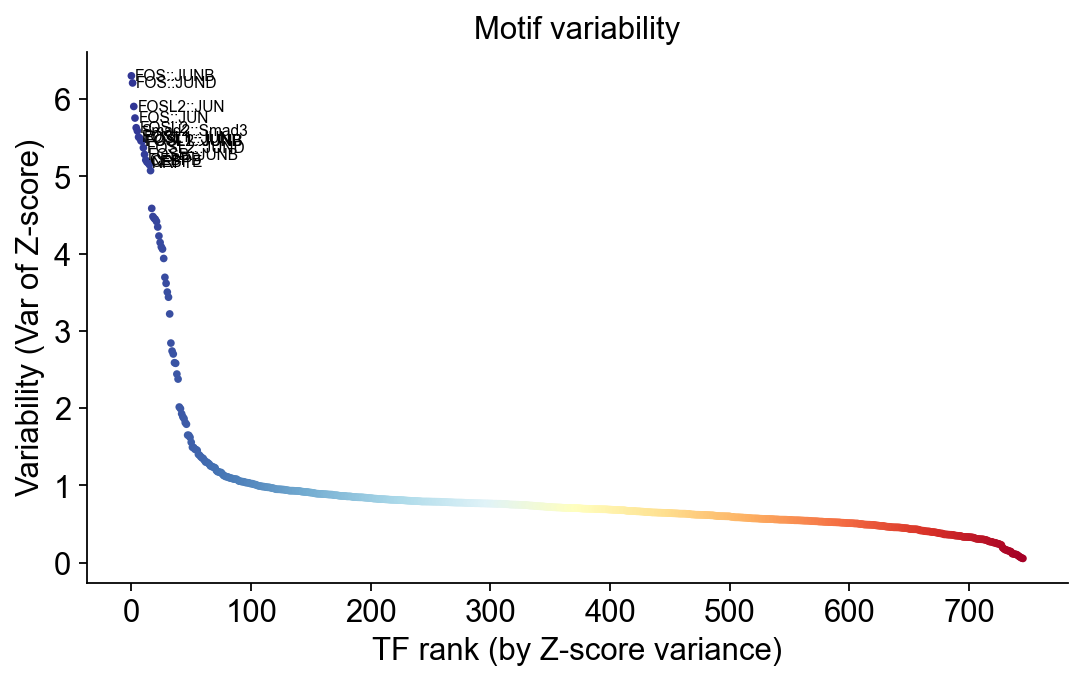

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(variability))
y = variability[rank]
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(x)))
ax.scatter(x, y, c=colors, s=6)
for i in range(15):
    ax.text(x[i] + 3, y[i], _tf_name(names[rank[i]]),
            fontsize=7, va='center', ha='left')
ax.set_xlabel('TF rank (by Z-score variance)')
ax.set_ylabel('Variability (Var of Z-score)')
ax.set_title('Motif variability')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); display(fig); plt.close(fig)


### Plot 2 · UMAP coloured by TF Z-score


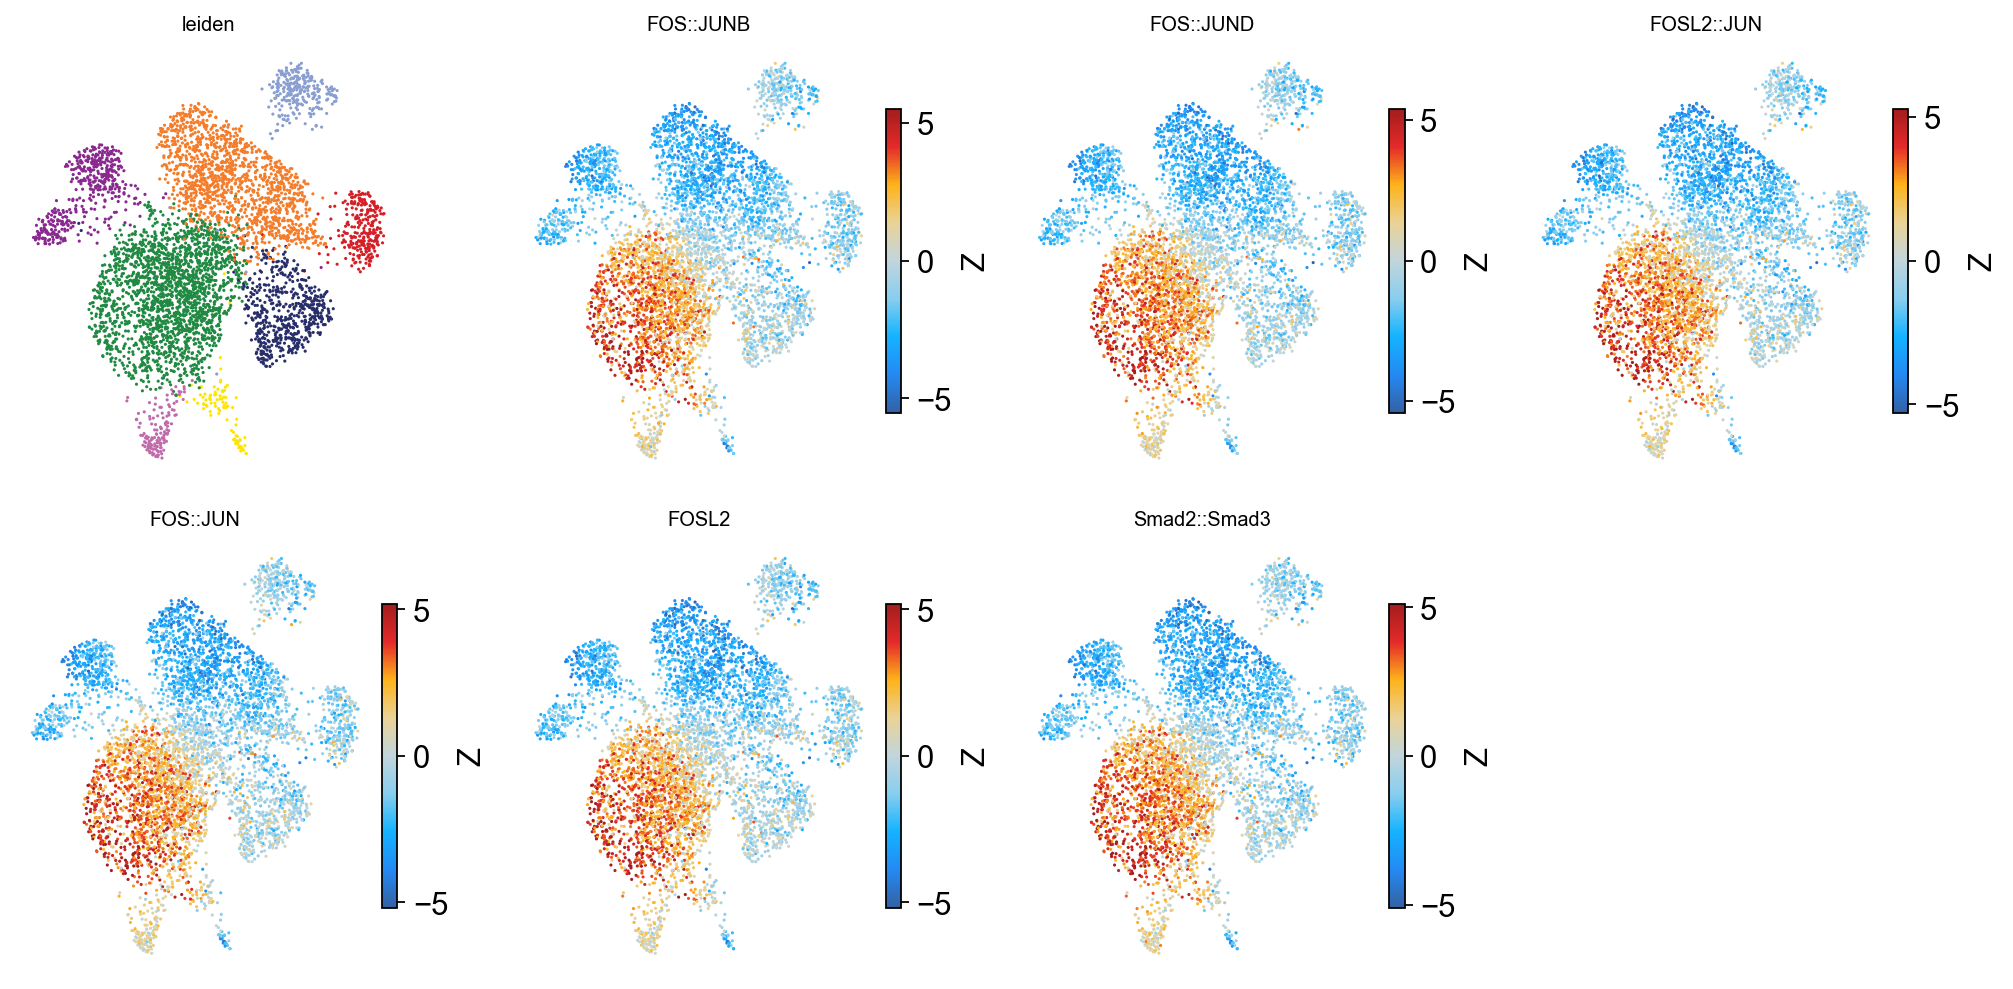

In [10]:
top_k = 6
panels = ['leiden'] + [names[rank[i]] for i in range(top_k)]
for j in range(top_k):
    adata.obs[names[rank[j]]] = Z[:, rank[j]]

ncols = (len(panels) + 1) // 2
fig, axes = plt.subplots(2, ncols, figsize=(3.2 * ncols, 6.4))
axes = axes.ravel()
umap = adata.obsm['X_umap']
for i, col in enumerate(panels):
    ax = axes[i]
    if col == 'leiden':
        cats = adata.obs['leiden'].astype('category').cat.categories
        pal = {c: ARCHR_STALLION[k % len(ARCHR_STALLION)]
               for k, c in enumerate(cats)}
        cvals = adata.obs['leiden'].map(pal).values
        ax.scatter(umap[:, 0], umap[:, 1], c=cvals, s=2, linewidths=0)
        ax.set_title('leiden', fontsize=9)
    else:
        v = adata.obs[col].to_numpy(dtype=np.float32)
        lo, hi = np.nanpercentile(v, [1, 99])
        m = max(abs(lo), abs(hi))
        sc_ = ax.scatter(umap[:, 0], umap[:, 1], c=v, s=2,
                         cmap=ARCHR_SOLAR, vmin=-m, vmax=m,
                         linewidths=0)
        plt.colorbar(sc_, ax=ax, fraction=0.05, pad=0.02,
                     shrink=0.7, label='Z')
        ax.set_title(_tf_name(col), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top','right','bottom','left']].set_visible(False)
for j in range(len(panels), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(); display(fig); plt.close(fig)


### Plot 3 · Per-cluster TF heatmap (`plotMarkerHeatmap`)


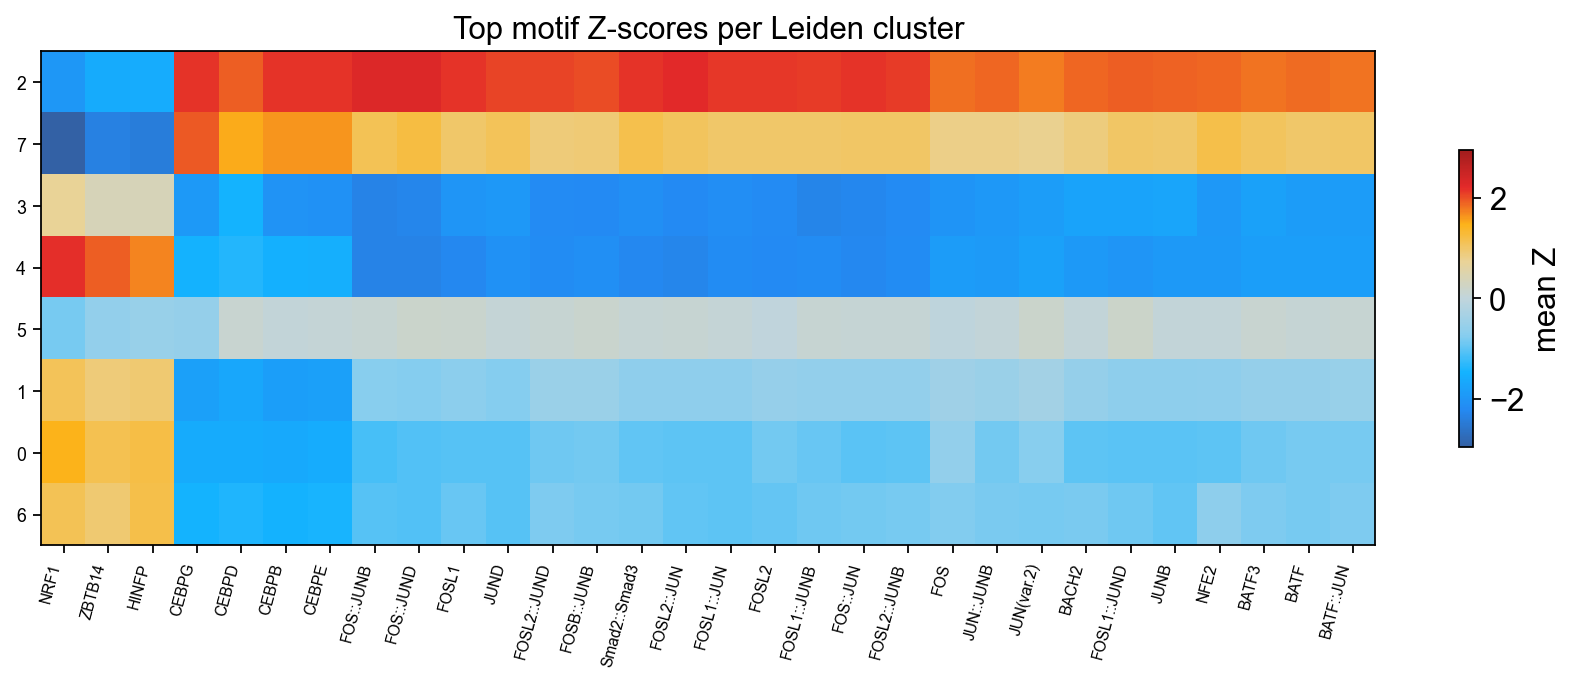

In [11]:
import scipy.cluster.hierarchy as sch

top_n = 30
tf_idx = rank[:top_n]
group = adata.obs['leiden'].astype('category')
cats = list(group.cat.categories)

heat = np.stack([
    np.nanmean(Z[group.values == c][:, tf_idx], axis=0)
    for c in cats
])

link_r = sch.linkage(heat.T, method='ward')
link_c = sch.linkage(heat,   method='ward')
row_order = sch.leaves_list(link_r)
col_order = sch.leaves_list(link_c)
H = heat[col_order][:, row_order]
tf_labels = [_tf_name(names[tf_idx[i]]) for i in row_order]
ct_labels = [cats[i] for i in col_order]

fig, ax = plt.subplots(figsize=(11, 4.5))
lim = float(np.nanmax(np.abs(H)))
im = ax.imshow(H, aspect='auto', cmap=ARCHR_SOLAR,
               vmin=-lim, vmax=lim, interpolation='nearest')
ax.set_yticks(range(len(ct_labels)))
ax.set_yticklabels(ct_labels, fontsize=8)
ax.set_xticks(range(len(tf_labels)))
ax.set_xticklabels(tf_labels, rotation=75, fontsize=7, ha='right')
plt.colorbar(im, ax=ax, shrink=0.6, label='mean Z')
ax.set_title('Top motif Z-scores per Leiden cluster')
plt.tight_layout(); display(fig); plt.close(fig)


## Notes

- `add_motif_matrix(motif_database=...)` skips MOODS entirely; use it whenever the same genome + motif collection + p-value is applied across multiple datasets (the usual case).
- `compute_deviations` also stores the uncorrected deviation in `obsm['motif_deviations_raw']` if you prefer the raw signal.
- Cross-validation on the ArchR hematopoiesis tutorial data: mean per-TF Pearson r = 0.94 across 746 motifs vs ArchR's own chromVAR output; top-100 variable TF overlap 98 / 100.
